# Lane Detection using OpenCV
##### Based on https://github.com/d-misra/Lane-detection-opencv-python

Modification made to fit the indoor setting of the geicar:
- Hough lines thereshold and min line length
- Mask to extract the black color of a picture
- Modification of the Hough-line averaging with pick_lane_lines to filter the raw Hough detection
- Modification to have utility functions reusable in the geicar architecture


In [41]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [42]:
#Utility functions

# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
def canny_edges_with_roi(
    binary_mask,
    canny_low=50,
    canny_high=150,
    roi_vertical_ratio=0.5
):
    edges = cv2.Canny(binary_mask, canny_low, canny_high)

    h, w = edges.shape[:2]
    roi_mask = np.zeros_like(edges)
    cv2.rectangle(
        roi_mask,
        (0, int(h * roi_vertical_ratio)),
        (w, h),
        255,
        -1
    )
    return cv2.bitwise_and(edges, roi_mask)


# Averages Hough segments into left/right lane(s)
def hough_lines(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=25,
    min_line_length=120,
    max_line_gap=30
):
    return cv2.HoughLinesP(
        edges,
        rho=rho,
        theta=theta,
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

# dark‑tape color mask
def dark_tape_mask(
    bgr_image,
    lower_dark=np.array([0, 0, 0]),
    upper_dark=np.array([180, 80, 120]),
    kernel_size=5
):
    hsv = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_dark, upper_dark)

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return mask

def pick_lane_lines(image_shape, lines, min_slope=0.2):
    if lines is None:
        return None

    h, w = image_shape[:2]
    left, right = [], []

    for l in lines:
        x1, y1, x2, y2 = l.reshape(4)
        if x2 == x1:
            continue

        m = (y2 - y1) / (x2 - x1)
        if abs(m) < min_slope:
            continue

        xm = 0.5 * (x1 + x2)
        if xm < w / 2:
            left.append((x1, y1, x2, y2))
        else:
            right.append((x1, y1, x2, y2))

    lanes = []
    if left:
        lanes.append(np.mean(left, axis=0).astype(int))
    if right:
        lanes.append(np.mean(right, axis=0).astype(int))

    return np.array(lanes) if lanes else None

def detect_lanes_dark_tape(
    inputimage,
    draw_fn,
    thickness=8
):
    mask = dark_tape_mask(inputimage)
    edges = canny_edges_with_roi(mask)
    lines = hough_lines(edges)
    lane_lines = pick_lane_lines(inputimage.shape, lines)

    output = draw_fn(inputimage, lane_lines, thickness=thickness)
    return output, lane_lines, edges, mask


# Draws lines of given thickness over an image
def draw_lines(image, lines, thickness):
    if lines is None:
        return image

    line_image = np.zeros_like(image)
    if len(line_image.shape) == 2:
        line_image = cv2.cvtColor(line_image, cv2.COLOR_GRAY2BGR)

    color = (0, 0, 255)
    for x1, y1, x2, y2 in lines:
        cv2.line(line_image, (x1, y1), (x2, y2), color, thickness)

    combined_image = cv2.addWeighted(image, 0.8, line_image, 1.0, 0.0)
    return combined_image


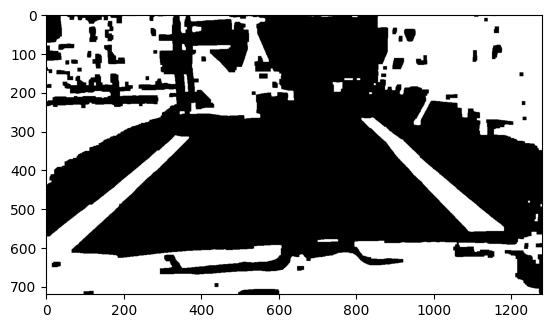

In [43]:
# Load input image (ideally this should be a frame extracted from a video)
inputimage = cv2.imread("image_test.jpg")

plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage with
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))


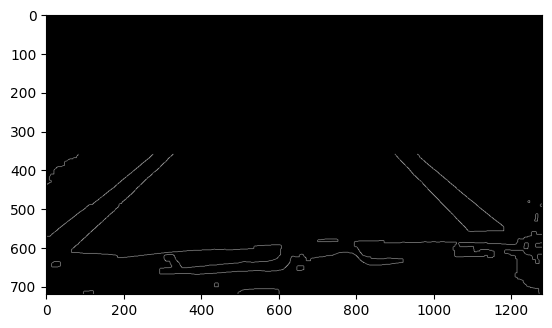

In [44]:
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

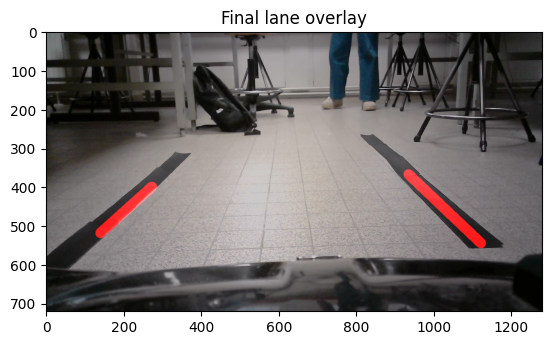

In [45]:
output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()


In [46]:
x_center = inputimage.shape[1] / 2.0
print("center in x:", x_center)

center in x: 640.0


#### Code to detect the error with the center of the lane

In [47]:
def x_interpolation(line, y):
    x1, y1, x2, y2 = line
    return x1 + (y - y1) * (x2 - x1) / (y2 - y1)

def compute_lane_center_error(lane_lines, image_shape, y_ratio=0.75):

    h, w = image_shape[:2]
    y_ref = int(y_ratio * h) # close to the car (bottom of the picture)
    
    if lane_lines is None:
        # No lanes detected
        return None, None
    
    if len(lane_lines) == 1:
        # TO DO
        return None, None
    else:
        x_left  = x_interpolation(lane_lines[0], y_ref)
        x_right = x_interpolation(lane_lines[1], y_ref)
        x_lane_center = (x_left + x_right)/2
    
    x_image_center = w / 2.0
    error_px = x_image_center - x_lane_center
    
    return x_lane_center, error_px


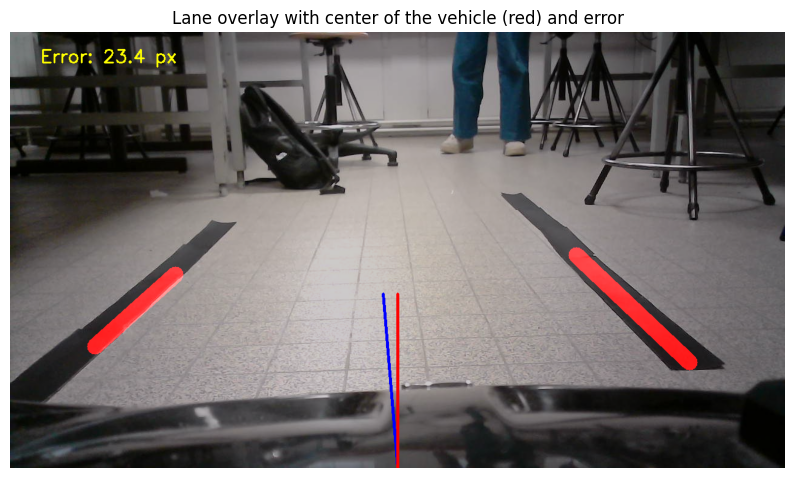

In [48]:
h, w = inputimage.shape[:2]
y2 = h  # bottom of the image
y1 = int(0.6 * h)  # top of the line, e.g., ROI top
x_image_center = w // 2

# Draw a vertical line for the lane center
x_lane_center, error_px = compute_lane_center_error(lanes,inputimage.shape)

# Draw lane center
cv2.line(output, (int(x_lane_center), y1), (int(x_image_center), y2), (255, 0, 0), 4)
# Draw image center (vehicle center)
cv2.line(output, (x_image_center, y1), (x_image_center, y2), (0, 0, 255), 4)
# Put error text
cv2.putText(output, f"Error: {error_px:.1f} px", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

# Display the picture with the lanes as before
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Lane overlay with center of the vehicle (red) and error")
plt.axis('off')
plt.show()